In [1]:
import os

# Must be set before any numerical library is imported
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"       # If using Intel MKL
os.environ["NUMEXPR_NUM_THREADS"] = "1"   # If using NumExpr
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"  # macOS Accelerate framework

# For Latex (get path from `which latex`)
latex_path = "/Library/TeX/texbin"
os.environ["PATH"] = latex_path+":" + os.environ["PATH"]

import numpy as np
import scipy as sp
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal,norm
from collections import defaultdict
import warnings
import sklearn.exceptions
from scipy.special import erfinv
from sklearn.metrics import precision_score, recall_score, f1_score
from tqdm.notebook import tqdm
from types import SimpleNamespace
import pickle

from _util import *

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage{amsmath} \usepackage{amssymb}"
})

warnings.filterwarnings("ignore", category=sklearn.exceptions.ConvergenceWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)

np.set_printoptions(edgeitems=30, linewidth=100000, formatter=dict(float=lambda x: "%.3g" % x))
make_plot = lambda n,m,s=[1,1],sharex=False, sharey=False: plt.subplots(n,m,figsize=(m*3*s[0],n*2.5*s[1]),squeeze=False,layout='tight',sharex=sharex, sharey=sharey)

# Data Prep.

In [2]:
from sklearn.preprocessing import quantile_transform

data = pd.read_csv("./data/gene/data.csv",index_col=0) # First colum is lables
data = data.to_numpy() # n x p
Y = quantile_transform(
    data,
    axis=0,
    n_quantiles=30,
    output_distribution="normal",
    random_state=0,
    copy=True,
).T

print(Y.shape)

# Adjecency matrix (threasholde to 0.5) as per queation
A_ref = pd.read_csv("./data/gene/reference_matrix_prob.csv",index_col=0) # First colum is lables
A_ref = A_ref.to_numpy()
A_ref = ((A_ref + A_ref.T) > 0.5) * 1.0 + np.eye(A_ref.shape[0]) # put on the diagional but it dosent really matter
print(A_ref.shape)

(100, 60)
(100, 100)


# Estimation

The error message `Error: C_true @ iC is not SPD` is normal, as the resulting metrics reported are related more to the nonzero structure of the matrix. The negative log-likelihood is measured from the data `Y` and the estimated `iC` and `C`.

In [3]:
import os
import pickle
from functools import partial

result = {}
results_metrics = {}

folder = "gene"
os.makedirs(f"./results/{folder}", exist_ok=True)

jobs = {
    "aquic-1": partial(compute_aquic, Y, c=1),
    "aquic-5": partial(compute_aquic, Y, c=5),
    "aquic-30": partial(compute_aquic, Y, c=30),
    "cv-glasso": partial(compute_glasso_cv, Y),
    "cv-quic": partial(compute_quic_cv, Y),
    "tiger": partial(compute_tiger, Y),
    "clime": partial(compute_clime, Y),
}

def run_method(name, func, folder, A_ref, Y):
    path = f"./results/{folder}/{name}.pkl"

    if os.path.exists(path):
        with open(path, "rb") as f:
            res = pickle.load(f)
    else:
        res = func()
        with open(path, "wb") as f:
            pickle.dump(res, f)

    return res, compute_metrics(result=res, C_true=None, iC_true=A_ref, Y=Y)

for name, func in jobs.items():
    # use A_ref as the true inverse pricsion matrix 
    # ... the errors computed are only valid in terms of the structure
    result[name], results_metrics[name] = run_method(name, func, folder, A_ref, Y)

methods = list(result.keys())
print(methods)

Error C_true @ iC is not SPD.
Error C_true @ iC is not SPD.
Error C_true @ iC is not SPD.
Error C_true @ iC is not SPD.
Error C_true @ iC is not SPD.
Error C_true @ iC is not SPD.
Error C_true @ iC is not SPD.
['aquic-1', 'aquic-5', 'aquic-30', 'cv-glasso', 'cv-quic', 'tiger', 'clime']


In [4]:
def metrics_to_df(results: dict, cols=None):                                               
      """                                                                                    
      results : {'method_name': SimpleNamespace(...), ...}
      cols    : list of metric names to keep (None = all)
      """                                                                                    
      default_cols = ['f1', 'precision', 'recall', 'nnz', 'nll', 'runtime']
      cols = cols or default_cols                                                            
                                                                                           
      rows = {name: {c: getattr(ns, c, float('nan')) for c in cols}
              for name, ns in results.items()}

      return pd.DataFrame(rows).T

metrics_to_df(results_metrics)

,f1,precision,recall,nnz,nll,runtime
aquic-1,0.319672,0.600000,0.217877,2.30,151.594065,0.005188
aquic-5,0.450839,0.394958,0.525140,5.76,137.135805,0.003209
aquic-30,0.327402,0.207831,0.770950,14.28,107.334862,0.016917
cv-glasso,0.345088,0.222764,0.765363,13.30,110.538598,4.603242
cv-quic,0.348158,0.225329,0.765363,13.16,111.333780,0.227992
tiger,0.022099,1.000000,0.011173,1.04,160.704457,1.629000
clime,0.021978,0.666667,0.011173,1.06,172.810327,0.783000


4.58
Saving figure to fig_gene.png


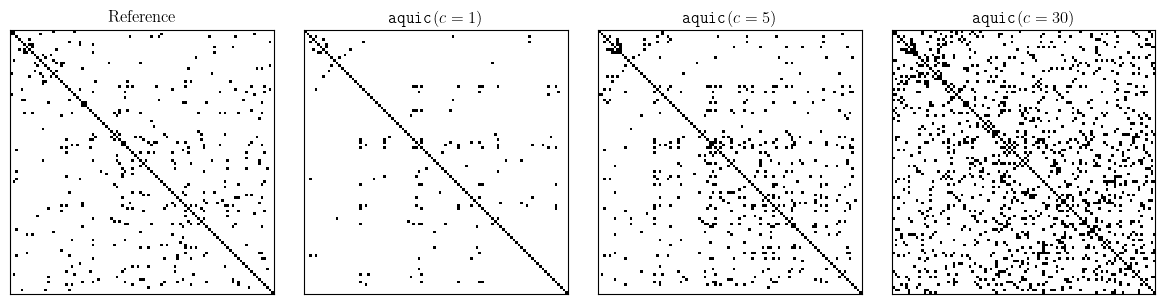

In [5]:
fig, ax = make_plot(1,4,s=[1,1.2])  # Adjust figsize for better viewing

print(np.count_nonzero(A_ref)/A_ref.shape[0])

ax[0,0].spy(A_ref)
ax[0,0].set_title('Reference')
ax[0,0].set_xticks([])
ax[0,0].set_yticks([])

m='aquic-1'
ax[0,1].spy(result[m].iC)
ax[0,1].set_title(r'$\texttt{aquic}\,(c=1)$')
ax[0,1].set_xticks([])
ax[0,1].set_yticks([])

m='aquic-5'
ax[0,2].spy(result[m].iC)
ax[0,2].set_title(r'$\texttt{aquic}\,(c=5)$')
ax[0,2].set_xticks([])
ax[0,2].set_yticks([])

m='aquic-30'
ax[0,3].spy(result[m].iC)
ax[0,3].set_title(r'$\texttt{aquic}\,(c=30)$')
ax[0,3].set_xticks([])
ax[0,3].set_yticks([])

plt.tight_layout()
fig.subplots_adjust(wspace=0.02, hspace=0.0)   # smaller gap between plots

# # Display the plot
fig_name='fig_gene.png'
print("Saving figure to", fig_name)
fig.savefig(fig_name, dpi=300)
w, h = fig.get_size_inches()
plt.show()